Power analysis for the effect size of the birth year coefficient

In [16]:
import statsmodels.formula.api as smf
import pandas as pd          
import matplotlib.pyplot as plt 
import numpy as np
from tqdm import tqdm

In [17]:
combined_df = pd.read_pickle('/home/gaia/Projects/legacy_data/combined_gm_volumes.pkl')
# keep only classification_label=1 and snbb
combined_df = combined_df[(combined_df['classification_label'] == 1) | (combined_df['source'] == 'snbb')]

In [18]:
min_age = 20
max_age = 25

# volumes df
volumes = combined_df[(combined_df['age_in_years'] >= min_age) & (combined_df['age_in_years'] < max_age)]

# metadata df
# remove duplicates based on subject_id
metadata = volumes.drop_duplicates(subset=['subject_id'])
print(f"shape of {min_age} - {max_age} years old metadata after removing duplicates: {metadata.shape}")

# type of values in the "age_at_scan" column
print(volumes['age_in_years'].dtype)

# 1. Convert the column to numeric (floats)
volumes['age_in_years'] = pd.to_numeric(volumes['age_in_years'], errors='coerce')

shape of 20 - 25 years old metadata after removing duplicates: (986, 25)
object


/tmp/ipykernel_506106/1360070684.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  volumes['age_in_years'] = pd.to_numeric(volumes['age_in_years'], errors='coerce')


In [19]:
n_list = [25, 33, 50, 70, 100, 135]
reps = 1000  # Number of random samplings per N
roi_of_interest = 453  
simulation_results = []

# Filter for the specific ROI first to speed up sampling
df_sim = volumes[volumes['region_label'] == roi_of_interest].copy()

In [20]:
# 2. Run Simulation
print(f"Starting simulation for ROI {roi_of_interest}...")
for n in tqdm(n_list):
    for r in range(reps):
        # Sample n scans randomly
        # replace=False ensures we don't pick the same scan twice in one sample
        sample_df = df_sim.sample(n=n, replace=False)
        
        try:
            # Fit the OLS model
            model = smf.ols(
                'volume_mm3 ~ birth_year + C(sex) + tiv + age_in_years',
                data=sample_df
            ).fit()
            
            # Extract the birth_year coefficient and its p-value
            # Note: The image shows Correlation (r), but since you are using OLS, 
            # we will store the standardized coefficient or the t-value.
            # To match the image perfectly, one might use Pearson's r, 
            # but here we'll use the Beta (coef).
            simulation_results.append({
                'sample_size': n,
                'iteration': r,
                'coef': model.params['birth_year'],
                'p_val': model.pvalues['birth_year'],
                't_val': model.tvalues['birth_year']
            })
        except:
            # Skip if model fails to converge for very small N
            continue

sim_df = pd.DataFrame(simulation_results)

# 3. Calculate Percentiles for CI Shading
stats = sim_df.groupby('sample_size')['coef'].agg([
    'mean',
    lambda x: np.percentile(x, 0.5),   # 99% Lower
    lambda x: np.percentile(x, 99.5),  # 99% Upper
    lambda x: np.percentile(x, 2.5),   # 95% Lower
    lambda x: np.percentile(x, 97.5)   # 95% Upper
]).reset_index()

stats.columns = ['sample_size', 'mean', 'low_99', 'high_99', 'low_95', 'high_95']

Starting simulation for ROI 453...


100%|██████████| 6/6 [00:25<00:00,  4.25s/it]


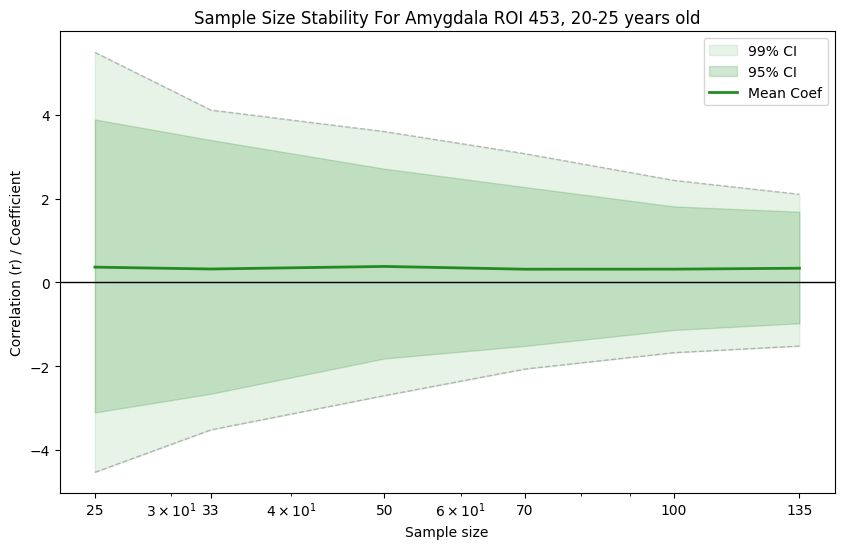

In [21]:
# 4. Create the Funnel Plot with CI Layers
plt.figure(figsize=(10, 6))

# --- Shading Layers ---
# 99% CI (Lightest/Outer)
plt.fill_between(stats['sample_size'], stats['low_99'], stats['high_99'], 
                 color='forestgreen', alpha=0.1, label='99% CI')

# 95% CI (Darker/Inner)
plt.fill_between(stats['sample_size'], stats['low_95'], stats['high_95'], 
                 color='forestgreen', alpha=0.2, label='95% CI')

# --- Border Lines ---
plt.plot(stats['sample_size'], stats['low_99'], color='gray', linestyle='--', lw=1, alpha=0.5)
plt.plot(stats['sample_size'], stats['high_99'], color='gray', linestyle='--', lw=1, alpha=0.5)

# --- Central Trend ---
plt.plot(stats['sample_size'], stats['mean'], color='forestgreen', lw=2, label='Mean Coef')

# Formatting
plt.xscale('log')
plt.xticks(n_list, labels=[str(x) for x in n_list])
plt.axhline(0, color='black', lw=1)
plt.xlabel('Sample size')
plt.ylabel('Correlation (r) / Coefficient')
plt.legend()
plt.title(f'Sample Size Stability For Amygdala ROI {roi_of_interest}, {min_age}-{max_age} years old')

plt.show()